In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

### Load dataset

In [2]:
data = pd.read_excel(r"C:\Users\msamp\Downloads\Delinquency_prediction_dataset.xlsx")

In [3]:
data.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [4]:
data.shape

(500, 19)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [6]:
data.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


In [7]:
data.columns = data.columns.str.lower().str.strip()

In [8]:
data.columns

Index(['customer_id', 'age', 'income', 'credit_score', 'credit_utilization',
       'missed_payments', 'delinquent_account', 'loan_balance',
       'debt_to_income_ratio', 'employment_status', 'account_tenure',
       'credit_card_type', 'location', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6'],
      dtype='object')

In [9]:
data.isna().sum()

customer_id              0
age                      0
income                  39
credit_score             2
credit_utilization       0
missed_payments          0
delinquent_account       0
loan_balance            29
debt_to_income_ratio     0
employment_status        0
account_tenure           0
credit_card_type         0
location                 0
month_1                  0
month_2                  0
month_3                  0
month_4                  0
month_5                  0
month_6                  0
dtype: int64

In [10]:
data['income'] = pd.to_numeric(data['income'], errors='coerce')

In [11]:
print(data['income'].dtype)

float64


#### handling the missing values

In [13]:
data['income'] = data['income'].fillna(data['income'].median())
data['loan_balance'] = data['loan_balance'].fillna(data['loan_balance'].median())
data['credit_score'] = data['credit_score'].fillna(data['credit_score'].median())

In [14]:
data['income']

0      165580.0
1      100999.0
2      188416.0
3      101672.0
4       38524.0
         ...   
495     48307.0
496     86180.0
497    152326.0
498    105852.0
499     40945.0
Name: income, Length: 500, dtype: float64

In [15]:
# specific value used to fill the nulls
print(f"The value used to fill nulls is: {data['income'].median()}")

The value used to fill nulls is: 107658.0


In [16]:
numeric_data = data.select_dtypes(include=['number'])

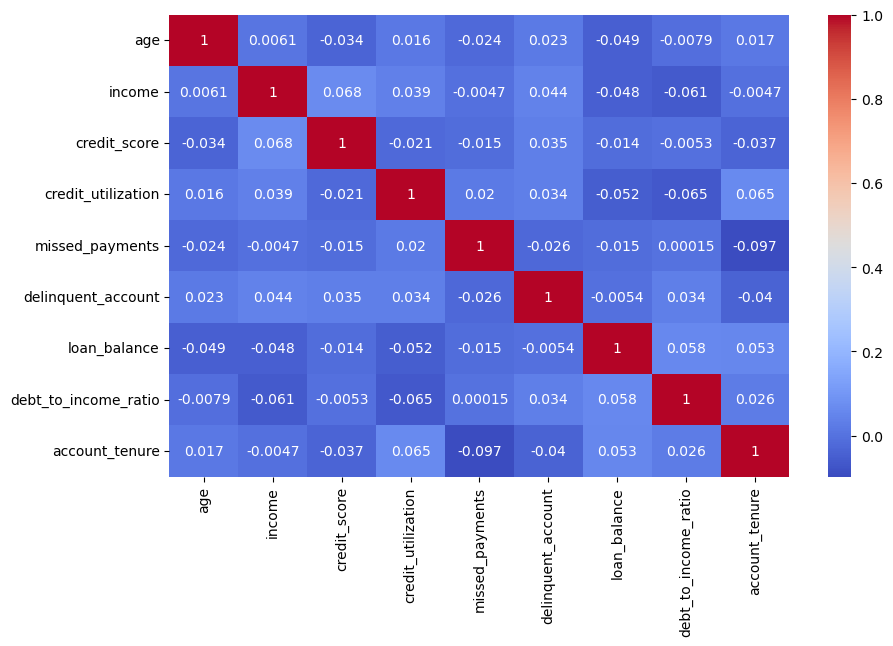

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

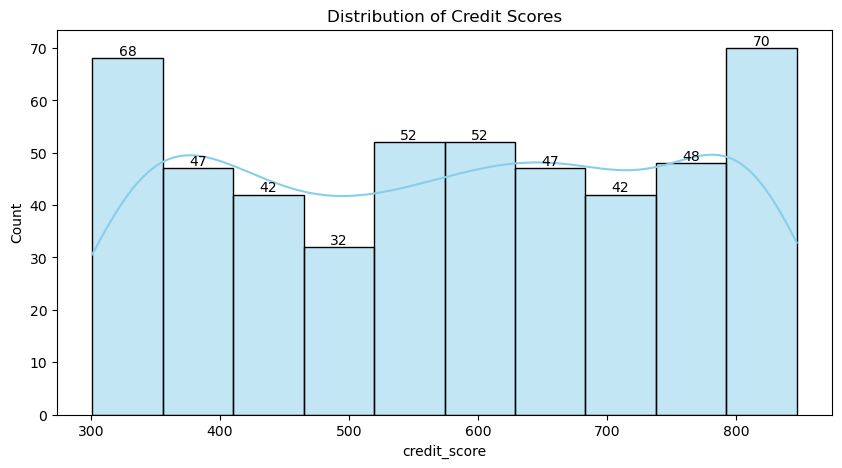

In [18]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(data['credit_score'], kde=True, color='skyblue')
for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Distribution of Credit Scores')
plt.show()

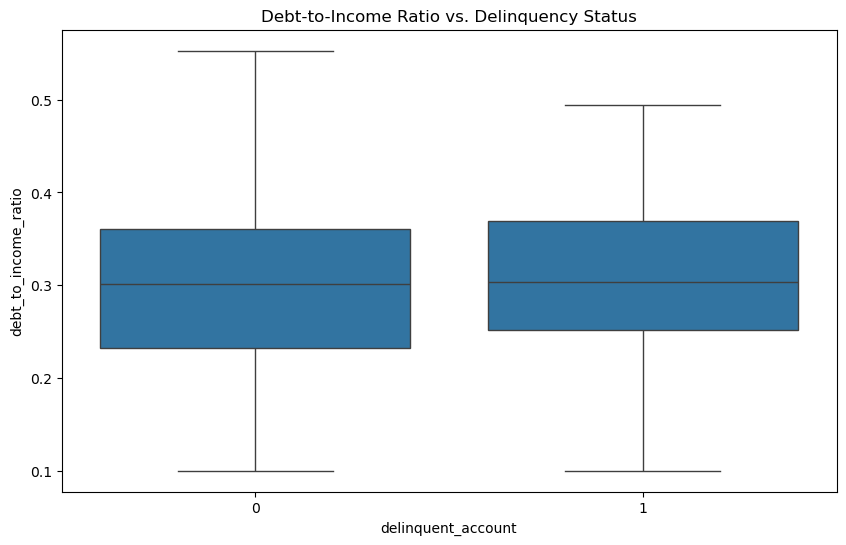

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='delinquent_account', y='debt_to_income_ratio', data=data)
plt.title('Debt-to-Income Ratio vs. Delinquency Status')
plt.show()

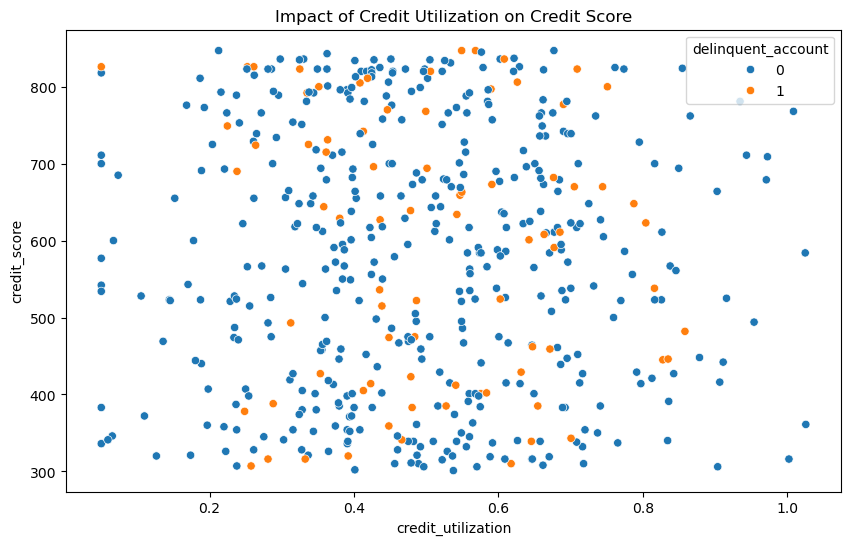

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='credit_utilization', y='credit_score', hue='delinquent_account', data=data)
plt.title('Impact of Credit Utilization on Credit Score')
plt.show()

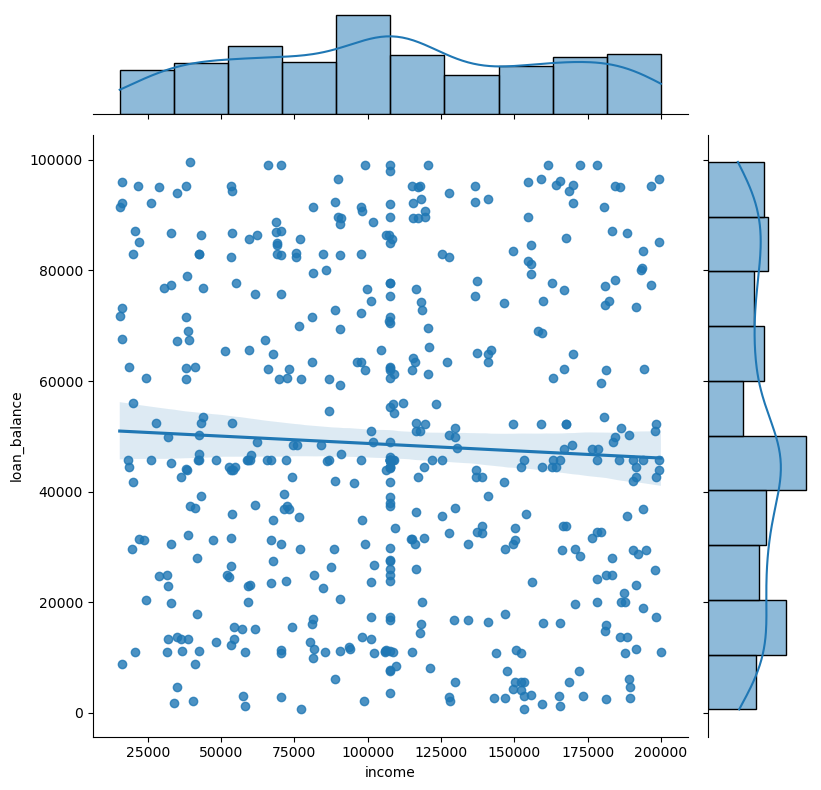

In [21]:
sns.jointplot(x='income', y='loan_balance', data=data, kind='reg', height=8)
plt.show()

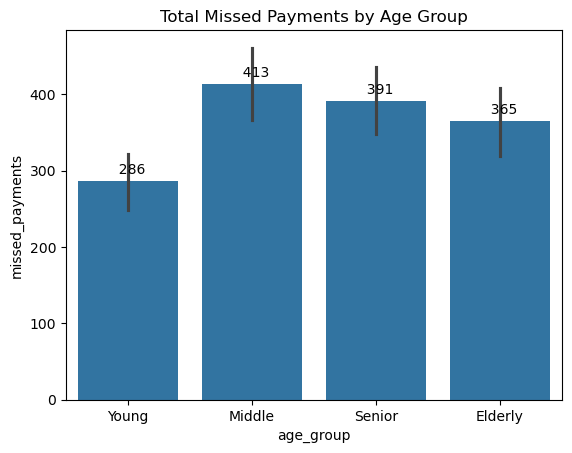

In [37]:
# Example of creating age bins first
data['age_group'] = pd.cut(data['age'], bins=[18, 30, 45, 60, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])
ax = sns.barplot(x='age_group', y='missed_payments', data=data, estimator=sum)
for i in ax.containers:
    ax.bar_label(i, padding=3, labels=[f'  {int(v.get_height())}' for v in i])
plt.title('Total Missed Payments by Age Group')
plt.show()

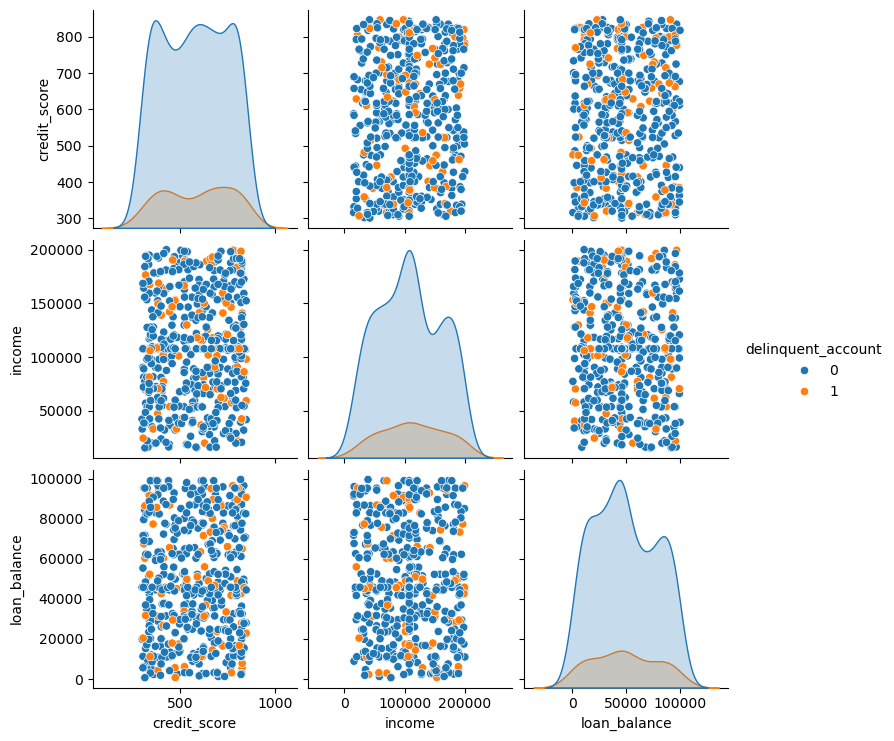

In [23]:
sns.pairplot(data[['credit_score', 'income', 'loan_balance', 'delinquent_account']], hue='delinquent_account')
plt.show()

### Feature Engineering 

In [24]:
# Create a Risk Factor to capture non-linear relationships
data['risk_factor'] = (data['missed_payments'] * data['credit_utilization']) / (data['credit_score'] / 100)

# Select only the most impactful features for the final model
features = ['credit_score', 'missed_payments', 'risk_factor', 'credit_utilization', 'debt_to_income_ratio']
X = data[features]
y = data['delinquent_account']

### Preprocessing

In [25]:
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Essential for Logistic Regression coefficients to be valid)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Final Model and Evaluation

In [26]:
# Initialize Logistic Regression with balanced weights for the minority class
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions and Results
y_pred = model.predict(X_test_scaled)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[40 46]
 [ 9  5]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.47      0.59        86
           1       0.10      0.36      0.15        14

    accuracy                           0.45       100
   macro avg       0.46      0.41      0.37       100
weighted avg       0.72      0.45      0.53       100



In [27]:
## Train and Evaluate

In [28]:
# Initialize and fit the model
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Make predictions
predictions = log_model.predict(X_test_scaled)

# See how it performed
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        86
           1       0.00      0.00      0.00        14

    accuracy                           0.86       100
   macro avg       0.43      0.50      0.46       100
weighted avg       0.74      0.86      0.80       100



### Feature Importance

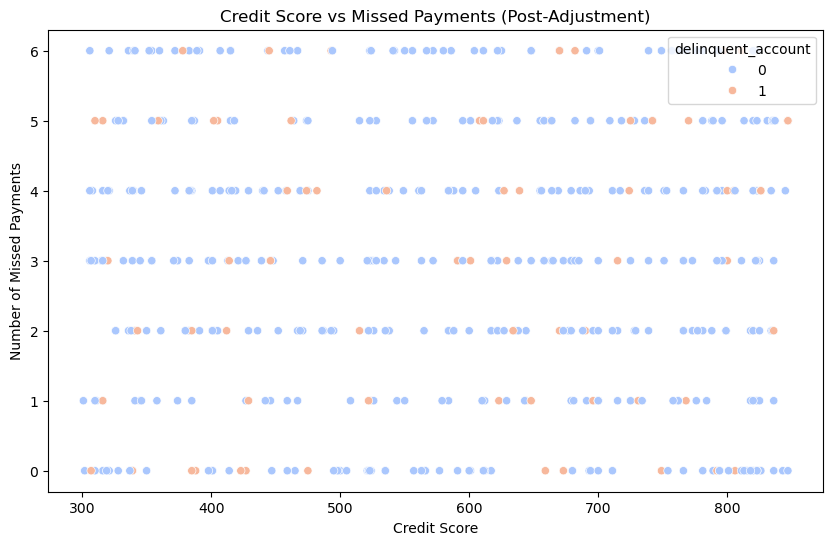

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='credit_score', y='missed_payments', hue='delinquent_account', data=data, palette='coolwarm')
plt.title('Credit Score vs Missed Payments (Post-Adjustment)')
plt.xlabel('Credit Score')
plt.ylabel('Number of Missed Payments')
plt.show()

In [39]:
# 1. Select the optimized features
features = ['credit_score', 'missed_payments', 'risk_factor', 'credit_utilization', 'debt_to_income_ratio']
X = data[features]
y = data['delinquent_account']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (Critical for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. The Improved Model (Using balanced weights)
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate the Results
y_pred = model.predict(X_test_scaled)

print("--- Improved Logistic Regression Results ---")
print(confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

--- Improved Logistic Regression Results ---
[[40 46]
 [ 9  5]]

               precision    recall  f1-score   support

           0       0.82      0.47      0.59        86
           1       0.10      0.36      0.15        14

    accuracy                           0.45       100
   macro avg       0.46      0.41      0.37       100
weighted avg       0.72      0.45      0.53       100



In [41]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Predict and evaluate
rf_pred = rf_model.predict(X_test_scaled)
print("--- Random Forest Results ---")
print(classification_report(y_test, rf_pred))

--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        86
           1       0.00      0.00      0.00        14

    accuracy                           0.86       100
   macro avg       0.43      0.50      0.46       100
weighted avg       0.74      0.86      0.80       100

